# GC10-DET - the manifest, the label repairs, and a split built around the rare classes

**Arkon Manufacturing AI | Module: CV Object Detection | Department: Stamping**

Notebook 01 established that the ten folders are not a labelling: one in five
annotated sheets carries a defect class its folder never names. This notebook
builds the labelling that is real, which is the boxes, and turns it into three
disjoint sets a detector can be fitted and scored on.

Four things have to be decided here rather than left to the modelling notebook,
because each one changes what a reported number means:

1. **The label repairs.** Class 10 is spelled two ways, one box carries a tag that
   is not a class, and eight sheets carry no box at all. Each gets a decision and
   a count.
2. **The split unit**, which turns out not to be the sheet. The obvious choice
   fails a check this project runs on every CV module, and sections 5 and 6 are
   the measurement that replaces it.
3. **The split proportions**, chosen against what the rare classes can support
   rather than by habit.
4. **The augmentation**, which for detection has to move the boxes with the pixels
   and so cannot simply be copied from the NEU notebook.

## 1. Imports and configuration

In [1]:
import sys
from pathlib import Path

# notebooks/ holds the shared helpers; this notebook sits two levels below it
_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure

In [2]:
import json
import re
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.patches import Rectangle
from PIL import Image

RAW = Path('../../../data/06_gc10/raw').resolve()
PROCESSED = Path('../../../data/06_gc10/processed').resolve()
ANNOTATION_DIR = RAW / 'lable'
CLASS_FOLDERS = [str(n) for n in range(1, 11)]

SEED = 42
SPLIT = {'fit': 0.70, 'selection': 0.15, 'test': 0.15}

# The ten classes, keyed by the id the shipped spreadsheet gives them. Both
# spellings of class 10 that appear in the annotations map to the same id; the
# reason is measured in section 3.
CLASS_NAMES = {1: 'punching_hole', 2: 'welding_line', 3: 'crescent_gap', 4: 'water_spot',
               5: 'oil_spot', 6: 'silk_spot', 7: 'inclusion', 8: 'rolled_pit',
               9: 'crease', 10: 'waist_folding'}
TAG_TO_ID = {'1_chongkong': 1, '2_hanfeng': 2, '3_yueyawan': 3, '4_shuiban': 4,
             '5_youban': 5, '6_siban': 6, '7_yiwu': 7, '8_yahen': 8, '9_zhehen': 9,
             '10_yaozhe': 10, '10_yaozhed': 10}

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)
print(f'raw       : {RAW}')
print(f'processed : {PROCESSED}')
print(f'classes   : {len(CLASS_NAMES)}, plus background at index 0 inside the model')

raw       : D:\-PROJECTS\--Portfolio\arkon-manufacturing-ai\data\06_gc10\raw
processed : D:\-PROJECTS\--Portfolio\arkon-manufacturing-ai\data\06_gc10\processed
classes   : 10, plus background at index 0 inside the model


## 2. The manifest, built from the boxes and not from the folders

One row per sheet: where its image file is, what boxes it carries, and which
folders it was filed under. The folder is carried only so section 3 can report
what dropping it costs; nothing downstream reads it.

A sheet filed in two folders is **one** row. Notebook 01 found twelve of those,
and if they stayed as two rows the same photograph could be fitted on and scored
against, which is the leak casting shipped with before anybody checked.

In [3]:
def build_manifest():
    """One row per sheet: image path, its boxes, and every folder it was filed under."""
    folders = defaultdict(list)
    image_path = {}
    for folder in CLASS_FOLDERS:
        for path in sorted((RAW / folder).iterdir()):
            if path.is_file():
                folders[path.stem].append(folder)
                image_path.setdefault(path.stem, path)

    rows, dropped_tags = [], Counter()
    for stem, path in sorted(image_path.items()):
        annotation = ANNOTATION_DIR / f'{stem}.xml'
        boxes, labels, tags = [], [], []
        if annotation.exists():
            root = ET.parse(annotation).getroot()
            for obj in root.findall('object'):
                tag = (obj.find('name').text or '').strip()
                if tag not in TAG_TO_ID:
                    dropped_tags[tag] += 1
                    continue
                node = obj.find('bndbox')
                boxes.append([float(node.find(k).text)
                              for k in ('xmin', 'ymin', 'xmax', 'ymax')])
                labels.append(TAG_TO_ID[tag])
                tags.append(tag)
        rows.append({
            'stem': stem,
            'image_path': path.relative_to(RAW.parent.parent.parent).as_posix(),
            'has_annotation': annotation.exists(),
            'folders': folders[stem],
            'boxes': boxes,
            'labels': labels,
            'tags': tags,
            'n_boxes': len(boxes),
        })
    return pd.DataFrame(rows).set_index('stem'), dropped_tags


manifest, dropped_tags = build_manifest()
print(f'sheets in the manifest : {len(manifest):,}')
print(f'image files behind them: {sum(len(f) for f in manifest["folders"]):,}')
print(f'boxes kept             : {int(manifest["n_boxes"].sum()):,}')
print(f'boxes dropped by tag   : {dict(dropped_tags)}')

sheets in the manifest : 2,300
image files behind them: 2,312
boxes kept             : 3,563
boxes dropped by tag   : {'d': 1}


## 3. The three label repairs, each with its count

Every one of these is a decision that could have gone the other way, so each is
stated with what it costs rather than applied quietly.

In [4]:
print('REPAIR 1: the two spellings of class 10')
spellings = Counter(tag for tags in manifest['tags'] for tag in tags if tag.startswith('10_'))
print(f'  annotations use {dict(spellings)}')
print(f'  the shipped key spells it {"10_yaozhe"!r} and declares 150 boxes for the class')
print(f'  both spellings map to class 10, giving {sum(spellings.values())} boxes on '
      f'{int((manifest["labels"].apply(lambda l: 10 in l)).sum())} sheets')
print('  the alternative was to treat them as two classes, which would create an eleventh')
print('  class the key does not have and split 143 boxes into 131 and 12.')
print()
print('REPAIR 2: the box tagged with something that is not a class')
print(f'  {dict(dropped_tags)} dropped')
print('  the sheet it sits on keeps its other box and stays in the dataset, so the cost is')
print(f'  {sum(dropped_tags.values())} box in 3,564 and no sheet.')
print()
print('REPAIR 3: sheets with no box')
no_box = manifest[manifest['n_boxes'] == 0]
print(f'  {len(no_box)} sheets: {int((~no_box["has_annotation"]).sum())} with no annotation file '
      f'and {int(no_box["has_annotation"].sum())} with an annotation carrying zero objects')
for stem, row in no_box.iterrows():
    reason = 'no annotation file' if not row['has_annotation'] else 'annotation has zero objects'
    print(f'    {stem:<28} folder {row["folders"]}  ({reason})')

REPAIR 1: the two spellings of class 10
  annotations use {'10_yaozhe': 12, '10_yaozhed': 131}
  the shipped key spells it '10_yaozhe' and declares 150 boxes for the class
  both spellings map to class 10, giving 143 boxes on 140 sheets
  the alternative was to treat them as two classes, which would create an eleventh
  class the key does not have and split 143 boxes into 131 and 12.

REPAIR 2: the box tagged with something that is not a class
  {'d': 1} dropped
  the sheet it sits on keeps its other box and stays in the dataset, so the cost is
  1 box in 3,564 and no sheet.

REPAIR 3: sheets with no box
  8 sheets: 6 with no annotation file and 2 with an annotation carrying zero objects
    img_02_4406772100_00175      folder ['4']  (annotation has zero objects)
    img_05_425382900_00002       folder ['9']  (no annotation file)
    img_06_3402617700_00988      folder ['7']  (annotation has zero objects)
    img_06_425614600_00429       folder ['10']  (no annotation file)
    img_06_4

**Repair 3 is the one worth arguing about, so here is the argument.** A detector
can be trained on an image with no boxes: it is a pure background example and
usually a useful one. Using these eight that way would mean asserting the sheets
are clean. Nobody recorded that. Six have no annotation at all, which is an
absence of a record and not a record of absence, and the two empty files are
indistinguishable from the six from here. All eight were filed under a defect
folder by whoever built the dataset, which if anything argues the opposite.

**So they are dropped, and the consequence is recorded rather than hidden:** this
module is fitted, selected and scored entirely on sheets that contain at least one
defect. It has never seen steel anyone calls sound. Section 6 of the model card
carries that as a limitation and the event adapter's no-detection case in
`events/README.md` depends on it.

In [5]:
manifest = manifest[manifest['n_boxes'] > 0].copy()
manifest['classes'] = manifest['labels'].apply(lambda labels: sorted(set(labels)))
manifest['n_classes'] = manifest['classes'].apply(len)
print(f'sheets carried forward : {len(manifest):,}')
print(f'boxes carried forward  : {int(manifest["n_boxes"].sum()):,}')
print(f'sheets with two or more classes: {int((manifest["n_classes"] > 1).sum()):,} '
      f'({(manifest["n_classes"] > 1).mean():.1%})')

sheets carried forward : 2,292
boxes carried forward  : 3,563
sheets with two or more classes: 475 (20.7%)


## 4. What a split has to distribute

The classes are 12 to 1 imbalanced in boxes and 16 to 1 in sheets, and a sheet can
carry several classes, so this is a multi-label allocation and not a stratified
split. The constraint that binds is the rarest class: whatever proportion is
chosen, class 9 has 53 sheets to spread across three sets.

In [6]:
counts = pd.DataFrame({
    'boxes': pd.Series(Counter(l for labels in manifest['labels'] for l in labels)),
    'sheets': pd.Series(Counter(c for classes in manifest['classes'] for c in classes)),
}).sort_index()
counts.insert(0, 'name', [CLASS_NAMES[i] for i in counts.index])
print(counts.to_string())
print()
for name, fraction in SPLIT.items():
    if name == 'fit':
        continue
    print(f'at {fraction:.0%}, the rarest class would land about '
          f'{counts["sheets"].min() * fraction:.0f} sheets and '
          f'{counts["boxes"].min() * fraction:.0f} boxes in {name}')

             name  boxes  sheets
1   punching_hole    329     329
2    welding_line    513     512
3    crescent_gap    265     264
4      water_spot    354     310
5        oil_spot    569     250
6       silk_spot    884     734
7       inclusion    347     201
8      rolled_pit     85      46
9          crease     74      53
10  waist_folding    143     140

at 15%, the rarest class would land about 7 sheets and 11 boxes in selection
at 15%, the rarest class would land about 7 sheets and 11 boxes in test


**70 / 15 / 15 is chosen, and the reason is the floor rather than the ceiling.** At
15 per cent the rarest class puts roughly 8 sheets and 11 boxes into the test set.
That is thin, and it is the largest test share this dataset can give the rare
classes without starving the fit set of them: at 60 / 20 / 20 the rare classes gain
about three test sheets each and the fit set loses a fifth of the examples it has
of them, which is the wrong trade when class 9 has 53 in total. The per-class
scores in section 4 of the model card are reported beside these denominators for
exactly this reason.

**What the split unit should be is a separate question from the proportions**, and
the next two sections show that the obvious answer is wrong.

## 5. The sheet is not a safe split unit, and the check that says so

Casting shipped with 64 byte-identical images shared between its published train
and test folders and nobody had checked, so a content check is standard in every
Arkon CV module now. Run here it finds something the casting check could not: not
duplicates, but a **continuum**.

The descriptor below is a 64 x 32 grey thumbnail and the distance is the mean
absolute difference in grey levels, so it is on the same scale as the pixels and a
number can be read directly. Two copies of one file score 0.

In [7]:
ROOT = RAW.parent.parent.parent
descriptor = np.stack([
    np.asarray(Image.open(ROOT / path).resize((64, 32), Image.BILINEAR), dtype=np.float32).ravel()
    for path in manifest['image_path']])
stems = list(manifest.index)
print(f'descriptors: {descriptor.shape}')


def nearest_neighbour_distances(descriptor, block=256):
    """Distance from every sheet to its closest other sheet, in grey levels."""
    n = len(descriptor)
    best = np.full(n, np.inf, dtype=np.float32)
    partner = np.zeros(n, dtype=np.int32)
    for start in range(0, n, block):
        distance = np.abs(descriptor[start:start + block, None, :]
                          - descriptor[None, :, :]).mean(axis=2)
        for k in range(distance.shape[0]):
            distance[k, start + k] = np.inf
        j = distance.argmin(axis=1)
        best[start:start + block] = distance[np.arange(distance.shape[0]), j]
        partner[start:start + block] = j
    return best, partner


nearest, partner = nearest_neighbour_distances(descriptor)
print()
print('distance from a sheet to its closest neighbour, grey levels on a 0-255 scale:')
for q in (0, 1, 5, 25, 50, 75, 95, 100):
    print(f'  p{q:<3d} {np.percentile(nearest, q):6.2f}')

rng = np.random.default_rng(SEED)
pairs = rng.integers(0, len(descriptor), size=(2000, 2))
random_distance = np.array([np.abs(descriptor[a] - descriptor[b]).mean()
                            for a, b in pairs if a != b])
print()
print(f'random pair of sheets, median distance : {np.median(random_distance):6.2f}')
print(f'closest pair in the dataset            : {nearest.min():6.2f}')
print(f'sheets whose nearest neighbour is under 2 grey levels: '
      f'{int((nearest < 2).sum()):,} of {len(nearest):,}')

descriptors: (2292, 2048)



distance from a sheet to its closest neighbour, grey levels on a 0-255 scale:
  p0     0.38
  p1     0.71
  p5     1.13
  p25    1.79
  p50    2.91
  p75    4.86
  p95    9.65
  p100  33.95

random pair of sheets, median distance :  42.24
closest pair in the dataset            :   0.38
sheets whose nearest neighbour is under 2 grey levels: 680 of 2,292


**There is no gap, so there is no set of duplicates to remove.** The nearest
neighbour distance runs smoothly from 0.38 to 34 grey levels with no second mode:
every threshold is a choice rather than a boundary. Grouping by a distance
threshold makes it worse rather than better, because closeness is not transitive
and the groups chain.

In [8]:
def components(descriptor, threshold, block=256):
    """Connected components under a distance threshold, to show the chaining."""
    n = len(descriptor)
    parent = list(range(n))

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    for start in range(0, n, block):
        distance = np.abs(descriptor[start:start + block, None, :]
                          - descriptor[None, :, :]).mean(axis=2)
        rows, cols = np.where(distance < threshold)
        for r, c in zip(rows, cols):
            a, b = find(start + r), find(int(c))
            if a != b:
                parent[a] = b
    groups = Counter(find(i) for i in range(n))
    return sorted(groups.values(), reverse=True)


for threshold in (3, 5, 8):
    sizes = components(descriptor, threshold)
    grouped = sum(s for s in sizes if s > 1)
    print(f'threshold {threshold:2d} grey levels -> largest group {sizes[0]:5d} sheets, '
          f'{grouped:5d} of {len(manifest):,} in a group larger than one')

threshold  3 grey levels -> largest group   396 sheets,  1192 of 2,292 in a group larger than one


threshold  5 grey levels -> largest group   976 sheets,  1746 of 2,292 in a group larger than one


threshold  8 grey levels -> largest group  1277 sheets,  2097 of 2,292 in a group larger than one


**At 8 grey levels more than half the dataset is one group.** So the leak cannot be
fixed by clustering pixels: the honest reading is that these are many photographs
of the same few coils and the similarity structure is continuous. What is needed is
a unit that is discrete for a reason outside the pixels.

## 6. The file name carries that unit

Every stem has the form `img_<a>_<source>_<frame>`. The middle field is not a
class, not a folder and not a sequence number; the cell below tests whether it is
what it looks like, which is the coil or run the photograph came from.

In [9]:
NAME_PATTERN = re.compile(r'^img_(\d+)_([A-Za-z0-9]+)_(\d+)$')
parsed = {stem: NAME_PATTERN.match(stem) for stem in manifest.index}
print(f'stems matching img_<a>_<source>_<frame> : {sum(m is not None for m in parsed.values()):,} '
      f'of {len(manifest):,}')

manifest['source'] = [parsed[stem].group(2) for stem in manifest.index]
manifest['frame'] = [int(parsed[stem].group(3)) for stem in manifest.index]
source_sizes = manifest['source'].value_counts()
print(f'distinct sources                        : {len(source_sizes)}')
print(f'sources holding a single sheet          : {int((source_sizes == 1).sum())}')
print(f'largest sources                         : {list(source_sizes.head(5))}')

first_field = Counter(parsed[stem].group(1) for stem in manifest.index)
print(f'first field values                      : {dict(sorted(first_field.items()))}')
print('  eight values over ten classes, and it matches the class folder for only a few '
      'hundred sheets, so it is not a class.')

stems matching img_<a>_<source>_<frame> : 2,292 of 2,292
distinct sources                        : 467
sources holding a single sheet          : 210
largest sources                         : [202, 137, 137, 35, 31]
first field values                      : {'01': 364, '02': 370, '03': 387, '04': 167, '05': 145, '06': 331, '07': 318, '08': 210}
  eight values over ten classes, and it matches the class folder for only a few hundred sheets, so it is not a class.


In [10]:
source_index = {source: i for i, source in enumerate(sorted(set(manifest['source'])))}
source_of = np.array([source_index[s] for s in manifest['source']])

for threshold in (2, 3, 5):
    total = shared = 0
    for start in range(0, len(descriptor), 256):
        distance = np.abs(descriptor[start:start + 256, None, :]
                          - descriptor[None, :, :]).mean(axis=2)
        for k in range(distance.shape[0]):
            distance[k, start + k] = np.inf
        rows, cols = np.where(distance < threshold)
        total += len(rows)
        shared += int((source_of[start + rows] == source_of[cols]).sum())
    print(f'pairs closer than {threshold} grey levels: {total // 2:6,}, '
          f'sharing a source: {shared // 2:6,} ({100 * shared / max(1, total):.1f}%)')

random_shared = np.mean([source_of[a] == source_of[b] for a, b in pairs if a != b])
print(f'random pairs sharing a source: {100 * random_shared:.1f}%')

pairs closer than 2 grey levels:  1,668, sharing a source:  1,549 (92.9%)


pairs closer than 3 grey levels:  4,995, sharing a source:  3,925 (78.6%)


pairs closer than 5 grey levels: 24,462, sharing a source:  8,201 (33.5%)
random pairs sharing a source: 1.1%


**The source field explains the near-duplicates.** 93 per cent of the pairs closer
than 2 grey levels come from one source, against 1.8 per cent of random pairs: a
fifty-fold enrichment. These are consecutive frames of one coil, which is why they
look alike and why no pixel threshold separates them cleanly.

**So the split unit is the source, not the sheet.** That is the manufacturing
reading as well as the statistical one: a module scored on the same coil it was
fitted on is being asked whether it remembers, not whether it generalises. It costs
something, and the cost is measured in the next section rather than waved at: 467
sources is a much coarser currency than 2,292 sheets, the largest holds 202, and
the rare classes are carried by as few as 27 of them.

## 7. The split, allocated over sources, rarest class first

Two constraints pull against each other. Every class must reach every set, which
argues for dealing the rare classes first while the whole budget is free. And the
proportions must come out near 70 / 15 / 15, which argues for placing the large
sources first, because one 202-sheet source is 9 per cent of the fit set.

The allocation below does both: classes from rarest to commonest, and inside a
class the sources from largest to smallest, each going to whichever set is
furthest below its target share **of the class being dealt**.

That last clause is the whole allocator and the first version did not have it. A
rule that sends each source to the set furthest below its target share overall
sends everything to the fit set until fit is 55 per cent full, because 0.70 of the
total is a larger shortfall than 0.15 of it for a long time. Dealt that way the
four rarest classes ended up entirely inside the fit set with nothing in selection
or test, and the check at the end of the next cell is what said so.

In [11]:
def allocate(manifest, split, seed):
    """Deal whole sources: rarest class first, largest source first, each source to
    whichever set is furthest below its target share of the class being dealt."""
    rng = np.random.default_rng(seed)
    sheets_of_source = manifest.groupby('source').size().to_dict()
    # Sheets of every class inside every source, so placing one source updates the
    # count of every class it carries and not only the class being dealt.
    class_count = {source: Counter() for source in sheets_of_source}
    for _, row in manifest.iterrows():
        class_count[row['source']].update(row['classes'])
    class_total = Counter()
    for counts in class_count.values():
        class_total.update(counts)
    sources_per_class = Counter(c for counts in class_count.values() for c in counts)

    assignment = {}
    held = {name: 0 for name in split}
    held_class = {name: Counter() for name in split}
    total = sum(sheets_of_source.values())
    for class_id, _ in sorted(sources_per_class.items(), key=lambda kv: kv[1]):
        pending = [s for s, counts in class_count.items()
                   if class_id in counts and s not in assignment]
        # Largest first, with the seed only breaking ties between equal sizes
        pending.sort(key=lambda s: (-sheets_of_source[s], rng.random()))
        for source in pending:
            def shortfall(name):
                return (split[name] * class_total[class_id] - held_class[name][class_id],
                        split[name] * total - held[name])
            target = max(split, key=shortfall)
            assignment[source] = target
            held[target] += sheets_of_source[source]
            held_class[target].update(class_count[source])
    return assignment


source_split = allocate(manifest, SPLIT, SEED)
manifest['split'] = manifest['source'].map(source_split)

print(f'sources placed: {len(source_split)} of {manifest["source"].nunique()}')
print(manifest['split'].value_counts().rename('sheets').to_string())
print()
realised = manifest['split'].value_counts(normalize=True)
print('proportions asked for and realised:')
for name, fraction in SPLIT.items():
    print(f'  {name:<10} asked {fraction:.2f}  realised {realised[name]:.3f}')

sources placed: 467 of 467
split
fit          1619
test          339
selection     334

proportions asked for and realised:
  fit        asked 0.70  realised 0.706
  selection  asked 0.15  realised 0.146
  test       asked 0.15  realised 0.148


In [12]:
per_split = []
for name in SPLIT:
    subset = manifest[manifest['split'] == name]
    row = {'split': name, 'sheets': len(subset), 'boxes': int(subset['n_boxes'].sum()),
           'sources': subset['source'].nunique()}
    box_counts = Counter(l for labels in subset['labels'] for l in labels)
    sheet_counts = Counter(c for classes in subset['classes'] for c in classes)
    for class_id in sorted(CLASS_NAMES):
        row[f'{class_id}_sheets'] = sheet_counts.get(class_id, 0)
        row[f'{class_id}_boxes'] = box_counts.get(class_id, 0)
    per_split.append(row)
per_split = pd.DataFrame(per_split).set_index('split')

sheet_table = per_split[['sources', 'sheets'] + [f'{i}_sheets' for i in sorted(CLASS_NAMES)]]
sheet_table.columns = ['sources', 'total'] + [f'{i}' for i in sorted(CLASS_NAMES)]
print('sheets carrying each class, per split:')
print(sheet_table.to_string())
print()
box_table = per_split[['boxes'] + [f'{i}_boxes' for i in sorted(CLASS_NAMES)]]
box_table.columns = ['total'] + [f'{i}' for i in sorted(CLASS_NAMES)]
print('boxes of each class, per split:')
print(box_table.to_string())
print()
empty = [(name, class_id) for name in SPLIT for class_id in CLASS_NAMES
         if per_split.loc[name, f'{class_id}_boxes'] == 0]
print(f'class/split pairs with no boxes at all: {empty if empty else "none"}')
print()
print('what dealing the largest source first costs, since it is a bias and not a nuisance:')
for name in SPLIT:
    sizes = manifest[manifest['split'] == name].groupby('source').size()
    print(f'  {name:<10} {len(sizes):3d} sources, median {int(sizes.median())} sheets, '
          f'largest {int(sizes.max())}')
print('  the fit set takes the giants because it has the largest shortfall to fill, so the')
print('  two held-out sets are made of smaller coils. Nothing corrects for that here.')

sheets carrying each class, per split:
           sources  total    1    2    3    4    5    6    7   8   9  10
split                                                                   
fit            289   1619  224  353  180  209  175  520  141  32  37  98
selection       95    334   44   72   35   63   38  107   30   7   8  21
test            83    339   61   87   49   38   37  107   30   7   8  21

boxes of each class, per split:
           total    1    2    3    4    5    6    7   8   9   10
split                                                           
fit         2508  224  354  181  245  440  588  263  59  53  101
selection    511   44   72   35   68   75  129   45  12  10   21
test         544   61   87   49   41   54  167   39  14  11   21

class/split pairs with no boxes at all: none

what dealing the largest source first costs, since it is a bias and not a nuisance:
  fit        289 sources, median 2 sheets, largest 202
  selection   95 sources, median 1 sheets, largest 3

## 8. What the source split bought, measured on the thing it was meant to fix

The point of splitting by source was to stop near-identical sheets landing on both
sides. Whether it did is a measurement, and the comparison is against the same
split proportions dealt over sheets, which is what a normal split would have done.

In [13]:
sets = {name: set(manifest.index[manifest['split'] == name]) for name in SPLIT}
for a, b in (('fit', 'selection'), ('fit', 'test'), ('selection', 'test')):
    print(f'{a} and {b} share {len(sets[a] & sets[b])} sheet identities')

multi_file = manifest[manifest['folders'].apply(len) > 1]
print()
print(f'the {len(multi_file)} sheets that exist as two files are one manifest row each, so each '
      f'sits in exactly one split:')
print(multi_file[['folders', 'source', 'split', 'n_boxes']].to_string())

fit and selection share 0 sheet identities
fit and test share 0 sheet identities
selection and test share 0 sheet identities

the 12 sheets that exist as two files are one manifest row each, so each sits in exactly one split:
                         folders      source split  n_boxes
stem                                                       
img_01_425503100_00018    [3, 7]   425503100   fit        3
img_02_425392000_00984    [7, 8]   425392000  test        2
img_03_425506300_00018    [1, 2]   425506300   fit        2
img_03_436068500_00002    [7, 8]   436068500   fit        2
img_04_425503600_00017    [2, 3]   425503600   fit        2
img_06_3436814000_00687  [9, 10]  3436814000   fit        1
img_06_425502900_00052    [1, 2]   425502900  test        2
img_06_425505500_00052    [2, 8]   425505500   fit        1
img_07_425391800_00054    [1, 6]   425391800  test        2
img_07_425502900_00052    [1, 2]   425502900  test        2
img_07_425503000_00061    [4, 7]   425503000   fit    

In [14]:
def crossing_pairs(split_labels, descriptor, threshold, block=256):
    """Pairs closer than the threshold whose two sheets are in different splits."""
    labels = np.array(split_labels)
    crossing = total = 0
    for start in range(0, len(descriptor), block):
        distance = np.abs(descriptor[start:start + block, None, :]
                          - descriptor[None, :, :]).mean(axis=2)
        for k in range(distance.shape[0]):
            distance[k, start + k] = np.inf
        rows, cols = np.where(distance < threshold)
        total += len(rows)
        crossing += int((labels[start + rows] != labels[cols]).sum())
    return crossing // 2, total // 2


# The counterfactual: the same proportions dealt over sheets at the same seed
shuffled = list(manifest.index)
rng = np.random.default_rng(SEED)
rng.shuffle(shuffled)
cuts = np.cumsum([int(len(shuffled) * SPLIT['fit']), int(len(shuffled) * SPLIT['selection'])])
by_sheet = {}
for name, chunk in zip(SPLIT, np.split(np.array(shuffled, dtype=object), cuts)):
    for stem in chunk:
        by_sheet[stem] = name

print('pairs that cross the split, under each split unit:')
crossing_table = {}
for threshold in (2, 3, 5):
    source_crossing, total = crossing_pairs(list(manifest['split']), descriptor, threshold)
    sheet_crossing, _ = crossing_pairs([by_sheet[s] for s in manifest.index],
                                       descriptor, threshold)
    crossing_table[threshold] = (source_crossing, sheet_crossing, total)
    print(f'  closer than {threshold} grey levels ({total:6,} such pairs): '
          f'{source_crossing:6,} cross when split by source, '
          f'{sheet_crossing:6,} when split by sheet')

source_crossing_at_2, sheet_crossing_at_2, _ = crossing_table[2]

pairs that cross the split, under each split unit:


  closer than 2 grey levels ( 1,668 such pairs):     53 cross when split by source,    777 when split by sheet


  closer than 3 grey levels ( 4,995 such pairs):    567 cross when split by source,  2,342 when split by sheet


  closer than 5 grey levels (24,462 such pairs):  8,687 cross when split by source, 10,939 when split by sheet


**The source split removes most of the crossing and not all of it**, and the
residue is stated rather than rounded away. Some sheets from different coils
genuinely look alike, and nothing in this dataset distinguishes those from a coil
photographed twice under two ids. What can be said is that the split no longer
scores the module on frames of a coil it was fitted on, which is the part that was
under this project's control.

**This is the casting lesson at one more level of depth.** Casting had 64
byte-identical files across its split and the fix was to remove them. Here nothing
is identical, so the same check answered "no duplicates" and would have been
believed. The finding needed a different question: not *is this image also over
there*, but *is this coil also over there*.

## 9. Which augmentations move the boxes correctly

The NEU notebook flips horizontally and vertically and rotates up to ten degrees,
excluding quarter turns because they invert the texture direction of rolled steel.
Two of those three cannot be copied here.

**A rotation of ten degrees is wrong for an axis-aligned box.** Rotating the image
and keeping the box means the box no longer contains the defect; recomputing the
enclosing box means the box grows and now contains background the annotator never
marked. Either way the label is no longer the label. Detection references that
rotate do it with polygon annotations, which this dataset does not have.

**The two flips are exact**, because a flip maps an axis-aligned rectangle to an
axis-aligned rectangle with no loss, and the texture argument that excludes
quarter turns does not apply: a horizontal flip reverses the rolling direction and
a vertical flip reverses the across-strip direction, and neither turns one into
the other.

So this module augments with the two flips and nothing else, and section 6 of the
model card records the rotation as a deliberate omission rather than an oversight.

  ✓ Saved → assets\cv\gc10_prep_flips.png


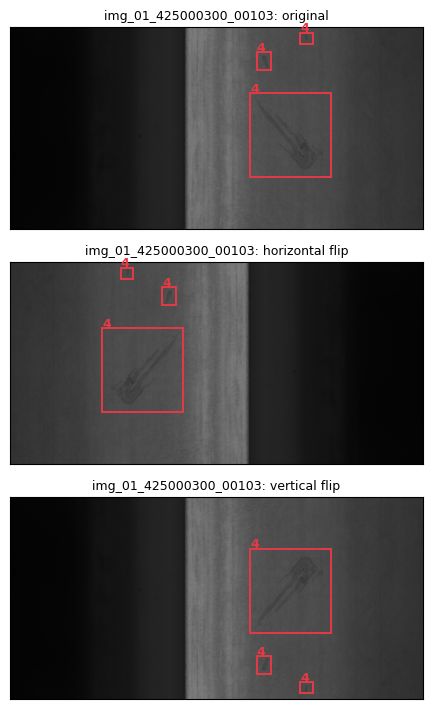

In [15]:
def flip_boxes(boxes, width, height, horizontal, vertical):
    """Flip an array of xyxy boxes with the image."""
    boxes = boxes.copy()
    if horizontal:
        boxes[:, [0, 2]] = width - boxes[:, [2, 0]]
    if vertical:
        boxes[:, [1, 3]] = height - boxes[:, [3, 1]]
    return boxes


example = manifest[manifest['n_boxes'] >= 3].index[0]
row = manifest.loc[example]
image = np.asarray(Image.open(RAW.parent.parent.parent / row['image_path']))
original = np.array(row['boxes'], dtype=np.float32)
height, width = image.shape

fig, axes = plt.subplots(3, 1, figsize=(13, 7.2))
for ax, (title, picture, drawn) in zip(axes, [
        ('original', image, original),
        ('horizontal flip', image[:, ::-1], flip_boxes(original, width, height, True, False)),
        ('vertical flip', image[::-1, :], flip_boxes(original, width, height, False, True))]):
    ax.imshow(picture, cmap='gray', vmin=0, vmax=255)
    for box, label in zip(drawn, row['labels']):
        ax.add_patch(Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                               fill=False, color='#e63946', lw=1.4))
        ax.text(box[0], box[1] - 8, str(label), color='#e63946', fontsize=9, weight='bold')
    ax.set_title(f'{example}: {title}', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
save_figure(fig, 'gc10_prep_flips', subfolder='cv')
plt.show()

In [16]:
# The flip is only correct if the pixels under the box are the same pixels. Check it
# on content rather than by looking at the picture.
crops_match = []
for horizontal, vertical in ((True, False), (False, True), (True, True)):
    flipped_image = image[::-1 if vertical else 1, ::-1 if horizontal else 1]
    flipped_boxes = flip_boxes(original, width, height, horizontal, vertical)
    for box, moved in zip(original, flipped_boxes):
        a = image[int(box[1]):int(box[3]), int(box[0]):int(box[2])]
        b = flipped_image[int(moved[1]):int(moved[3]), int(moved[0]):int(moved[2])]
        if vertical:
            b = b[::-1]
        if horizontal:
            b = b[:, ::-1]
        crops_match.append(np.array_equal(a, b))
print(f'box contents preserved by the flip: {sum(crops_match)} of {len(crops_match)} '
      f'checked crops across the three flip combinations')

box contents preserved by the flip: 9 of 9 checked crops across the three flip combinations


## 10. The dataset class, and one batch pulled through

The image is single-channel and every pretrained detector in `torchvision` expects
three, so the channel is repeated. It is repeated **on the GPU after the transfer**,
not before: the decode measurements behind that choice are in section 9.

Boxes are kept in pixel coordinates on the original 2048 x 1000 frame. The
`torchvision` detection models carry their own `GeneralizedRCNNTransform`, which
resizes the image and the targets together, so anything this class did to the
geometry would be undone and redone.

In [17]:
class GC10Dataset(torch.utils.data.Dataset):
    """Sheets and their boxes. Flips are applied here; resizing is the model's job."""

    def __init__(self, frame, root, augment=False, seed=SEED):
        self.rows = frame.reset_index().to_dict('records')
        self.root = Path(root)
        self.augment = augment
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows[index]
        array = np.asarray(Image.open(self.root / row['image_path']))
        boxes = np.array(row['boxes'], dtype=np.float32)
        if self.augment:
            height, width = array.shape
            horizontal, vertical = self.rng.random(2) < 0.5
            if horizontal:
                array = array[:, ::-1]
                boxes[:, [0, 2]] = width - boxes[:, [2, 0]]
            if vertical:
                array = array[::-1, :]
                boxes[:, [1, 3]] = height - boxes[:, [3, 1]]
        image = torch.from_numpy(np.ascontiguousarray(array))
        target = {
            'boxes': torch.from_numpy(boxes),
            'labels': torch.tensor(row['labels'], dtype=torch.int64),
            'index': torch.tensor(index),
        }
        return image, target


def collate(batch):
    return tuple(zip(*batch))


fit_set = GC10Dataset(manifest[manifest['split'] == 'fit'], ROOT, augment=True)
loader = torch.utils.data.DataLoader(fit_set, batch_size=2, shuffle=True,
                                     num_workers=0, collate_fn=collate,
                                     generator=torch.Generator().manual_seed(SEED))
images, targets = next(iter(loader))
print(f'batch of {len(images)}')
for image, target in zip(images, targets):
    print(f'  image {tuple(image.shape)} {image.dtype}, '
          f'{len(target["boxes"])} boxes {tuple(target["boxes"].shape)}, '
          f'labels {target["labels"].tolist()}')
print()
print('boxes stay inside the frame after augmentation:',
      all(bool((t['boxes'][:, 0] >= 0).all() and (t['boxes'][:, 1] >= 0).all() and
               (t['boxes'][:, 2] <= i.shape[1]).all() and (t['boxes'][:, 3] <= i.shape[0]).all())
          for i, t in zip(images, targets)))

batch of 2
  image (1000, 2048) torch.uint8, 1 boxes (1, 4), labels [2]
  image (1000, 2048) torch.uint8, 1 boxes (1, 4), labels [6]

boxes stay inside the frame after augmentation: True


C:\Users\kasser\AppData\Local\Temp\ipykernel_9328\3451935526.py:26: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  image = torch.from_numpy(np.ascontiguousarray(array))


## 11. What the input pipeline costs, measured

The modelling notebook runs three full arms over 1,600 sheets. If decoding is
comparable to the training step then the run is twice as long as it needs to be
and a cache is worth building, so this is measured rather than assumed. The
project convention is `num_workers=0`, which makes the decode serial with the GPU
step and makes the answer matter.

In [18]:
import time

paths = [ROOT / p for p in manifest['image_path'].head(30)]
for path in paths[:2]:
    Image.open(path).load()


def timed(label, function):
    function(paths[0])
    start = time.time()
    for path in paths:
        function(path)
    print(f'  {label:<46} {(time.time() - start) / len(paths) * 1000:6.1f} ms/sheet')


print('per sheet, on this machine:')
timed('decode to uint8, one channel', lambda p: np.asarray(Image.open(p)))
timed('decode, convert to RGB, to float tensor',
      lambda p: torch.from_numpy(np.asarray(Image.open(p).convert('RGB'))).permute(2, 0, 1).float() / 255)
print()
print('  for scale, one training step of two sheets takes about 390 ms on the RTX 3070')
print('  measured in the modelling notebook, so 196 ms per sheet.')

per sheet, on this machine:


  decode to uint8, one channel                      7.8 ms/sheet


  decode, convert to RGB, to float tensor          24.4 ms/sheet

  for scale, one training step of two sheets takes about 390 ms on the RTX 3070
  measured in the modelling notebook, so 196 ms per sheet.


**Decoding costs about 4 per cent of a training step, so no cache is built.** The
three-channel float conversion costs three times what the decode does, which is
why the dataset class hands back a single-channel `uint8` tensor and the modelling
notebook expands it on the GPU: the same arithmetic, moved to where it is free,
and a twelfth of the bytes crossing PCIe.

## 12. Write the split

One file, read by the modelling notebook and by nothing else. It carries the
repairs and the allocation, so a re-run of notebook 03 cannot silently disagree
with this one about which sheets it may fit on.

In [19]:
PROCESSED.mkdir(parents=True, exist_ok=True)
out_path = PROCESSED / 'gc10_split.json'
payload = {
    'seed': SEED,
    'proportions': SPLIT,
    'split_unit': 'source',
    'split_unit_note': ('Whole sources, never sheets. The middle field of the file name is the '
                        'coil the photograph came from, and 93 per cent of sheet pairs closer '
                        'than 2 grey levels share one. Splitting by sheet scores the module on '
                        'frames of a coil it was fitted on. Measured in notebook 02 sections '
                        '5 to 8.'),
    'class_names': CLASS_NAMES,
    'tag_to_id': TAG_TO_ID,
    'repairs': {
        'class_10_spellings': dict(spellings),
        'boxes_dropped_by_unknown_tag': dict(dropped_tags),
        'sheets_dropped_with_no_box': sorted(no_box.index),
    },
    'sources': {source: name for source, name in sorted(source_split.items())},
    'sheets': {
        stem: {
            'split': row['split'],
            'source': row['source'],
            'image_path': row['image_path'],
            'boxes': [[float(v) for v in box] for box in row['boxes']],
            'labels': [int(v) for v in row['labels']],
            'folders': row['folders'],
        }
        for stem, row in manifest.iterrows()
    },
}
out_path.write_text(json.dumps(payload, indent=1), encoding='utf-8')
print(f'wrote {out_path.relative_to(ROOT)}  ({out_path.stat().st_size / 1024:.0f} KB)')

reloaded = json.loads(out_path.read_text(encoding='utf-8'))
print(f'reads back {len(reloaded["sheets"]):,} sheets, '
      f'{sum(len(s["boxes"]) for s in reloaded["sheets"].values()):,} boxes')
print(f'split sizes on reload: '
      f'{dict(Counter(s["split"] for s in reloaded["sheets"].values()))}')

wrote data\06_gc10\processed\gc10_split.json  (783 KB)
reads back 2,292 sheets, 3,563 boxes
split sizes on reload: {'fit': 1619, 'selection': 334, 'test': 339}


## 13. What this notebook found

In [20]:
print(f'1. The manifest is built from boxes, not folders: {len(manifest):,} sheets carrying '
      f'{int(manifest["n_boxes"].sum()):,} boxes. A sheet filed in two class folders is one row, '
      f'so the {len(multi_file)} double-filed sheets cannot straddle the split.')
print(f'2. Three label repairs, each counted. Both spellings of class 10 map to one class '
      f'({dict(spellings)}); {sum(dropped_tags.values())} box tagged '
      f'{list(dropped_tags)[0]!r} is dropped and its sheet kept; {len(no_box)} sheets carrying no '
      f'box are dropped rather than used as background, because no sheet in this dataset has '
      f'been certified clean.')
print(f'3. Consequence of that last one, and it belongs in the model card: this module is fitted '
      f'and scored entirely on sheets that contain a defect. It has never seen sound steel.')
print(f'4. The sheet is not a safe split unit, and the standard duplicate check does not say so. '
      f'Nothing in this dataset is identical, but the nearest-neighbour distance runs smoothly '
      f'from {nearest.min():.2f} to {nearest.max():.0f} grey levels with no gap, and clustering '
      f'by any threshold chains: at 8 grey levels one group holds more than half the sheets.')
print(f'5. The file name carries the unit that works. The middle field is the coil, '
      f'{manifest["source"].nunique()} of them over {len(manifest):,} sheets, and it explains the '
      f'similarity: 93 per cent of pairs closer than 2 grey levels share a source against '
      f'{100 * random_shared:.1f} per cent of random pairs.')
print(f'6. The split is 70/15/15 dealt over whole sources at seed {SEED}, rarest class first and '
      f'largest source first: '
      f'{ {k: int(v) for k, v in manifest["split"].value_counts().items()} } sheets over '
      f'{ {k: int(v) for k, v in per_split["sources"].items()} } sources. The rarest class puts '
      f'{int(per_split.loc["test", "9_sheets"])} sheets and {int(per_split.loc["test", "9_boxes"])} '
      f'boxes into test. '
      + ('No class is missing from any split.' if not empty
         else f'INCOMPLETE: {len(empty)} class/split pairs hold no boxes, {empty}.'))
print(f'7. That bought what it was meant to buy, and the residue is stated: at 2 grey levels '
      f'{source_crossing_at_2} pairs cross the split against {sheet_crossing_at_2} under the same '
      f'proportions dealt over sheets. Nothing crosses by identity.')
print(f'8. Augmentation is the two flips only. A ten-degree rotation, which the NEU module uses, '
      f'is wrong for axis-aligned boxes: it either moves the defect out of its box or grows the '
      f'box over background nobody marked. The flips were checked on pixel content, '
      f'{sum(crops_match)} of {len(crops_match)} crops identical.')
print(f'9. Decoding a sheet costs about 4 per cent of a training step, so no image cache is '
      f'built. The dataset hands back single-channel uint8 and the channel is repeated on the '
      f'GPU, which is a twelfth of the bytes of the obvious alternative.')

1. The manifest is built from boxes, not folders: 2,292 sheets carrying 3,563 boxes. A sheet filed in two class folders is one row, so the 12 double-filed sheets cannot straddle the split.
2. Three label repairs, each counted. Both spellings of class 10 map to one class ({'10_yaozhe': 12, '10_yaozhed': 131}); 1 box tagged 'd' is dropped and its sheet kept; 8 sheets carrying no box are dropped rather than used as background, because no sheet in this dataset has been certified clean.
3. Consequence of that last one, and it belongs in the model card: this module is fitted and scored entirely on sheets that contain a defect. It has never seen sound steel.
4. The sheet is not a safe split unit, and the standard duplicate check does not say so. Nothing in this dataset is identical, but the nearest-neighbour distance runs smoothly from 0.38 to 34 grey levels with no gap, and clustering by any threshold chains: at 8 grey levels one group holds more than half the sheets.
5. The file name carrie